In [98]:
from pytorch_tabnet.tab_model import TabNetClassifier as tabnet
import utils as ut
import dataflow_pi_rating as pi
import os

In [99]:
# 1) Load data
# 2) Compute pi-ratings
# 3) Processing of features for tabnet
# 4) Split data
# 5) Define tabnet model
# 6) Train-Validate model
# 7) Predict test set

In [100]:
root_path = 'f:\\TFG\\'

In [101]:
data = ut.read_data(root_path+"datasets/raw_datasets/datalake.csv")
data

f:\TFG\code\experiments\utils.py:20: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(path,sep=';',decimal=',',parse_dates=['Date'],date_format="%d/%m/%Y")


,matchId,id_H,id_A,Div,div_order,Date,season,HomeTeam,AwayTeam,FTHG,...,AHW,B365H,B365D,B365A,MaxH,MaxD,MaxA,AvgH,AvgD,AvgA
0,0,8,19,D1,0,2000-11-08,T00-01,Dortmund,Hansa Rostock,1,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2,20,D1,1,2000-12-08,T00-01,Bayern Munich,Hertha,4,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,15,35,D1,2,2000-12-08,T00-01,Freiburg,Stuttgart,4,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,17,29,D1,3,2000-12-08,T00-01,Hamburg,Munich 1860,2,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,23,4,D1,4,2000-12-08,T00-01,Kaiserslautern,Bochum,0,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58541,58541,258,243,SP2,10828,2000-04-06,T99-00,Extremadura,Badajoz,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
58542,58542,271,274,SP2,10829,2000-04-06,T99-00,Las Palmas,Levante,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
58543,58543,277,314,SP2,10830,2000-04-06,T99-00,Logrones,Villarreal,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
58544,58544,288,297,SP2,10831,2000-04-06,T99-00,Osasuna,Recreativo,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [102]:
options = {
    "sample": "random",
    "init_date": "1996-07-01",
    "split_date": "2017-01-01",
    "save_data": True
}

In [103]:
pirating = pi.Dataflow_pi_rating(data,options)

INFO: Master class init


In [104]:
pirating.pi_ratings.sort_values("Date")

,matchId,Div,Date,id_H,id_A,HomeTeam,AwayTeam,FTHG,FTAG,FTR,rate_home,rate_away,new_rate_home,new_rate_away,rate_global,new_rate_global,gd_actual,gd_pred,error
35634,35634,I1,1996-07-01,184,147,Vicenza,Cremonese,1.0,0.0,H,0.025213,-0.184078,0.0,0.0,-0.079433,0.0,1.0,0.0,0.0
45862,45862,SP1,1996-07-01,206,191,La Coruna,Betis,0.0,0.0,D,0.543297,0.144872,0.0,0.0,0.344084,0.0,0.0,0.0,0.0
45861,45861,SP1,1996-07-01,198,227,Espanol,Valencia,2.0,0.0,H,0.199996,0.047035,0.0,0.0,0.123515,0.0,2.0,0.0,0.0
45860,45860,SP1,1996-07-01,193,190,Celta,Barcelona,1.0,0.0,H,-0.050983,0.443073,0.0,0.0,0.196045,0.0,1.0,0.0,0.0
35633,35633,I1,1996-07-01,179,166,Torino,Parma,2.0,2.0,D,0.016530,0.177667,0.0,0.0,0.097098,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34873,34873,I1,2021-12-05,139,153,Bologna,Genoa,0.0,2.0,A,0.003612,-0.153048,0.0,0.0,-0.074718,0.0,-2.0,0.0,0.0
34874,34874,I1,2021-12-05,154,172,Inter,Roma,3.0,1.0,H,0.192602,0.144429,0.0,0.0,0.168516,0.0,2.0,0.0,0.0
34876,34876,I1,2021-12-05,174,178,Sampdoria,Spezia,2.0,2.0,D,0.315891,0.000000,0.0,0.0,0.157946,0.0,0.0,0.0,0.0
44863,44863,SP1,2021-12-05,193,200,Celta,Getafe,1.0,0.0,H,-0.050983,0.000000,0.0,0.0,-0.025492,0.0,1.0,0.0,0.0


In [105]:
lamda, gamma = 0.01, 0.6

pirating.train_pi_rates(pirating.pi_ratings,lamda,gamma)

In [106]:
pirating.pi_ratings.sort_values("Date")

,matchId,Div,Date,id_H,id_A,HomeTeam,AwayTeam,FTHG,FTAG,FTR,rate_home,rate_away,new_rate_home,new_rate_away,rate_global,new_rate_global,gd_actual,gd_pred,error
35634,35634,I1,1996-07-01,184,147,Vicenza,Cremonese,1.0,0.0,H,-0.033716,-0.184078,-0.024685,-0.193109,-0.079433,0.0,1.0,-0.125538,0.903090
45862,45862,SP1,1996-07-01,206,191,La Coruna,Betis,0.0,0.0,D,0.587374,-0.747030,0.587374,-0.747030,0.344084,0.0,0.0,-0.204621,0.000000
45861,45861,SP1,1996-07-01,198,227,Espanol,Valencia,2.0,0.0,H,-0.324306,1.104497,-0.309993,1.090183,0.123515,0.0,2.0,-1.051717,1.431364
45860,45860,SP1,1996-07-01,193,190,Celta,Barcelona,1.0,0.0,H,-0.122638,5.403913,-0.113607,5.394882,0.196045,0.0,1.0,-62.186801,0.903090
35633,35633,I1,1996-07-01,179,166,Torino,Parma,2.0,2.0,D,-0.338427,-0.842384,-0.338427,-0.842384,0.097098,0.0,0.0,-0.612342,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34873,34873,I1,2021-12-05,139,153,Bologna,Genoa,0.0,2.0,A,-0.625609,-1.086730,-0.639922,-1.072416,-0.074718,0.0,-2.0,-0.686378,1.431364
34874,34874,I1,2021-12-05,154,172,Inter,Roma,3.0,1.0,H,3.428783,2.512448,3.443097,2.498134,0.168516,0.0,2.0,7.018892,1.431364
34876,34876,I1,2021-12-05,174,178,Sampdoria,Spezia,2.0,2.0,D,0.399358,-0.124933,0.399358,-0.124933,0.157946,0.0,0.0,0.258049,0.000000
44863,44863,SP1,2021-12-05,193,200,Celta,Getafe,1.0,0.0,H,-0.128056,-0.859305,-0.119025,-0.868336,-0.025492,0.0,1.0,-0.830625,0.903090


In [107]:
features = ["new_rate_home","new_rate_away"]

In [108]:
dataset = pirating.pi_ratings[features + ["matchId"]]
dataset.loc[:,"label"] = ut._create_label(pirating.pi_ratings,"FTR").FTR.astype(int)
dataset

,new_rate_home,new_rate_away,matchId,label
0,0.469877,-0.022695,0,1
1,0.466692,-0.018062,1,1
2,0.071377,-0.110957,2,1
3,-0.019417,-0.154629,3,0
4,0.256800,-0.132327,4,2
...,...,...,...,...
58541,0.068380,-0.137414,58541,0
58542,0.847521,0.104922,58542,1
58543,-0.176817,0.159513,58543,1
58544,0.352980,0.058595,58544,1


In [109]:
dataset.dtypes

new_rate_home    float64
new_rate_away    float64
matchId            int64
label              int32
dtype: object

In [110]:
dataset, train, test = ut.split_random(dataset,last_digits=[5,9])
_, train, validation = ut.split_random(train,last_digits=[3])

INFO: Train is  0.8000073784401978
INFO: Train is  0.8750518791791561


In [111]:
X_train = train[features].values
y_train = train["label"].values

X_valid = validation[features].values
y_valid = validation["label"].values

X_test = test[features].values
y_test = test["label"].values

print(X_train.shape, X_valid.shape, X_test.shape)
assert len(X_train)==len(y_train)
assert len(X_valid)==len(y_valid)
assert len(X_test)==len(y_test)

(37951, 2) (5419, 2) (10842, 2)


### SUPERVISED LEARNING

In [112]:
import torch

In [113]:
clf = tabnet(
    n_d=64, n_a=64, n_steps=5,
    gamma=1.5, n_independent=2, n_shared=2,
    cat_emb_dim=1,
    lambda_sparse=1e-3, momentum=0.3, clip_value=2.,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2),
    scheduler_params = {"gamma": 0.95,
                     "step_size": 20},
    scheduler_fn=torch.optim.lr_scheduler.StepLR, epsilon=1e-15
)

c:\Users\GuillemUPV\Anaconda3\envs\tfg\lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


In [114]:
bs = 1024 #16384

clf.fit(
    X_train=X_train, y_train=y_train,
    eval_set=[(X_train, y_train), (X_valid, y_valid)],
    eval_name=['train', 'valid'],
    max_epochs=50, patience=15,
    batch_size=bs, virtual_batch_size=128,
) 

epoch 0  | loss: 1.3065  | train_accuracy: 0.47551 | valid_accuracy: 0.47813 |  0:00:06s
epoch 1  | loss: 1.0363  | train_accuracy: 0.49393 | valid_accuracy: 0.49954 |  0:00:13s
epoch 2  | loss: 1.03786 | train_accuracy: 0.49548 | valid_accuracy: 0.49917 |  0:00:19s
epoch 3  | loss: 1.02773 | train_accuracy: 0.49461 | valid_accuracy: 0.50157 |  0:00:26s
epoch 4  | loss: 1.02881 | train_accuracy: 0.488   | valid_accuracy: 0.4916  |  0:00:32s
epoch 5  | loss: 1.02985 | train_accuracy: 0.49485 | valid_accuracy: 0.50101 |  0:00:38s
epoch 6  | loss: 1.03058 | train_accuracy: 0.48916 | valid_accuracy: 0.49087 |  0:00:45s
epoch 7  | loss: 1.027   | train_accuracy: 0.49627 | valid_accuracy: 0.50157 |  0:00:51s
epoch 8  | loss: 1.02691 | train_accuracy: 0.49675 | valid_accuracy: 0.49991 |  0:00:58s
epoch 9  | loss: 1.02631 | train_accuracy: 0.49667 | valid_accuracy: 0.50028 |  0:01:04s
epoch 10 | loss: 1.02607 | train_accuracy: 0.48702 | valid_accuracy: 0.49087 |  0:01:11s
epoch 11 | loss: 1.02

c:\Users\GuillemUPV\Anaconda3\envs\tfg\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


In [115]:
from matplotlib import pyplot as plt
%matplotlib inline

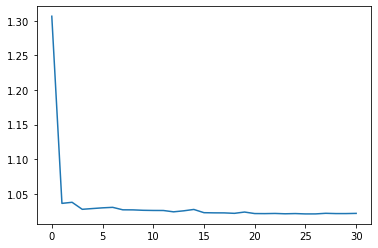

In [116]:
plt.plot(clf.history['loss'])

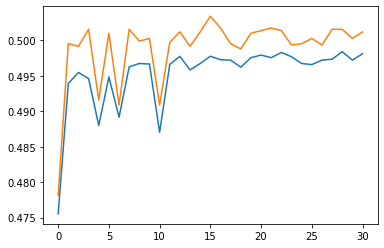

In [117]:
plt.plot(clf.history['train_accuracy'])
plt.plot(clf.history['valid_accuracy'])

In [118]:
logits = clf.predict_proba(X_test)

In [119]:
preds = logits.argmax(axis=1)
preds

array([1, 2, 1, ..., 1, 2, 1], dtype=int64)

In [120]:
clf.best_cost, clf.best_epoch

(0.5034139140062742, 15)

In [121]:
test_acc = (preds==y_test).mean()
test_acc

0.49787862018077844

#### LOSS as EVAL METRIC

In [122]:
clf_loss = tabnet(
    n_d=64, n_a=64, n_steps=5,
    gamma=1.5, n_independent=2, n_shared=2,
    cat_emb_dim=1,
    lambda_sparse=1e-3, momentum=0.3, clip_value=2.,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2),
    scheduler_params = {"gamma": 0.95,
                     "step_size": 20},
    scheduler_fn=torch.optim.lr_scheduler.StepLR, epsilon=1e-15
)

c:\Users\GuillemUPV\Anaconda3\envs\tfg\lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


In [123]:
bs = 1024 #16384

clf_loss.fit(
    X_train=X_train, y_train=y_train,
    eval_set=[(X_train, y_train), (X_valid, y_valid)],
    eval_name=['train', 'valid'],
    eval_metric=['logloss'],
    max_epochs=50, patience=15,
    batch_size=bs, virtual_batch_size=128,
) 

epoch 0  | loss: 1.3065  | train_logloss: 1.04979 | valid_logloss: 1.05126 |  0:00:06s
epoch 1  | loss: 1.0363  | train_logloss: 1.03338 | valid_logloss: 1.03274 |  0:00:13s
epoch 2  | loss: 1.03786 | train_logloss: 1.0296  | valid_logloss: 1.0316  |  0:00:20s
epoch 3  | loss: 1.02773 | train_logloss: 1.03161 | valid_logloss: 1.03241 |  0:00:26s
epoch 4  | loss: 1.02881 | train_logloss: 1.04415 | valid_logloss: 1.04527 |  0:00:33s
epoch 5  | loss: 1.02985 | train_logloss: 1.02348 | valid_logloss: 1.02428 |  0:00:40s
epoch 6  | loss: 1.03058 | train_logloss: 1.02784 | valid_logloss: 1.02916 |  0:00:46s
epoch 7  | loss: 1.027   | train_logloss: 1.02294 | valid_logloss: 1.02068 |  0:00:53s
epoch 8  | loss: 1.02691 | train_logloss: 1.02642 | valid_logloss: 1.0289  |  0:00:59s
epoch 9  | loss: 1.02631 | train_logloss: 1.02314 | valid_logloss: 1.02442 |  0:01:06s
epoch 10 | loss: 1.02607 | train_logloss: 1.03033 | valid_logloss: 1.03146 |  0:01:13s
epoch 11 | loss: 1.02601 | train_logloss: 1

c:\Users\GuillemUPV\Anaconda3\envs\tfg\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


In [124]:
from matplotlib import pyplot as plt
%matplotlib inline

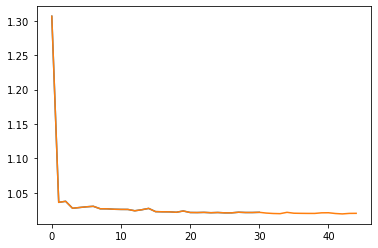

In [125]:
plt.plot(clf.history['loss'])
plt.plot(clf_loss.history['loss'])

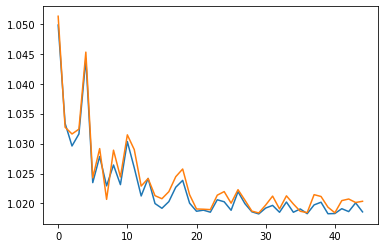

In [127]:
plt.plot(clf_loss.history['train_logloss'])
plt.plot(clf_loss.history['valid_logloss'])

In [128]:
logits_loss = clf_loss.predict_proba(X_test)

In [129]:
preds_loss = logits_loss.argmax(axis=1)
preds_loss

array([1, 2, 1, ..., 1, 2, 1], dtype=int64)

In [130]:
clf_loss.best_cost, clf_loss.best_epoch

(1.0184166815986402, 29)

In [131]:
test_acc_loss = (preds_loss==y_test).mean()
test_acc_loss

0.497970854085962

### UNSUPERVISED LEARNING

In [132]:
from pytorch_tabnet.tab_model import TabNetClassifier as tabnet
from pytorch_tabnet.pretraining import TabNetPretrainer

In [133]:
# TabNetPretrainer
unsupervised_model = TabNetPretrainer(
    n_d=64, n_a=64, n_steps=5,
    gamma=1.5, n_independent=2, n_shared=2,
    cat_emb_dim=1,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2),
    mask_type='entmax' # "sparsemax"
)

c:\Users\GuillemUPV\Anaconda3\envs\tfg\lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


In [134]:
unsupervised_model.fit(
    X_train=X_train,
    eval_set=[X_valid],
    pretraining_ratio=0.8,
)

epoch 0  | loss: 4.93713 | val_0_unsup_loss_numpy: 3.0048000812530518|  0:00:05s
epoch 1  | loss: 1.03212 | val_0_unsup_loss_numpy: 1.6118700504302979|  0:00:10s
epoch 2  | loss: 0.99187 | val_0_unsup_loss_numpy: 3.065190076828003|  0:00:15s
epoch 3  | loss: 1.00938 | val_0_unsup_loss_numpy: 3.6640799045562744|  0:00:19s
epoch 4  | loss: 0.97952 | val_0_unsup_loss_numpy: 0.6528800129890442|  0:00:24s
epoch 5  | loss: 0.97943 | val_0_unsup_loss_numpy: 1.6526000499725342|  0:00:29s
epoch 6  | loss: 0.97977 | val_0_unsup_loss_numpy: 2.559079885482788|  0:00:34s
epoch 7  | loss: 0.97253 | val_0_unsup_loss_numpy: 1.3351999521255493|  0:00:38s
epoch 8  | loss: 0.97239 | val_0_unsup_loss_numpy: 0.47086000442504883|  0:00:43s
epoch 9  | loss: 0.96708 | val_0_unsup_loss_numpy: 0.7980200052261353|  0:00:48s
epoch 10 | loss: 0.97509 | val_0_unsup_loss_numpy: 1.7359999418258667|  0:00:53s
epoch 11 | loss: 0.9628  | val_0_unsup_loss_numpy: 1.6228699684143066|  0:00:58s
epoch 12 | loss: 0.95888 | va

c:\Users\GuillemUPV\Anaconda3\envs\tfg\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


In [135]:
# Make reconstruction from a dataset
reconstructed_X, embedded_X = unsupervised_model.predict(X_valid)
assert(reconstructed_X.shape==embedded_X.shape)

In [136]:
unsupervised_explain_matrix, unsupervised_masks = unsupervised_model.explain(X_valid)

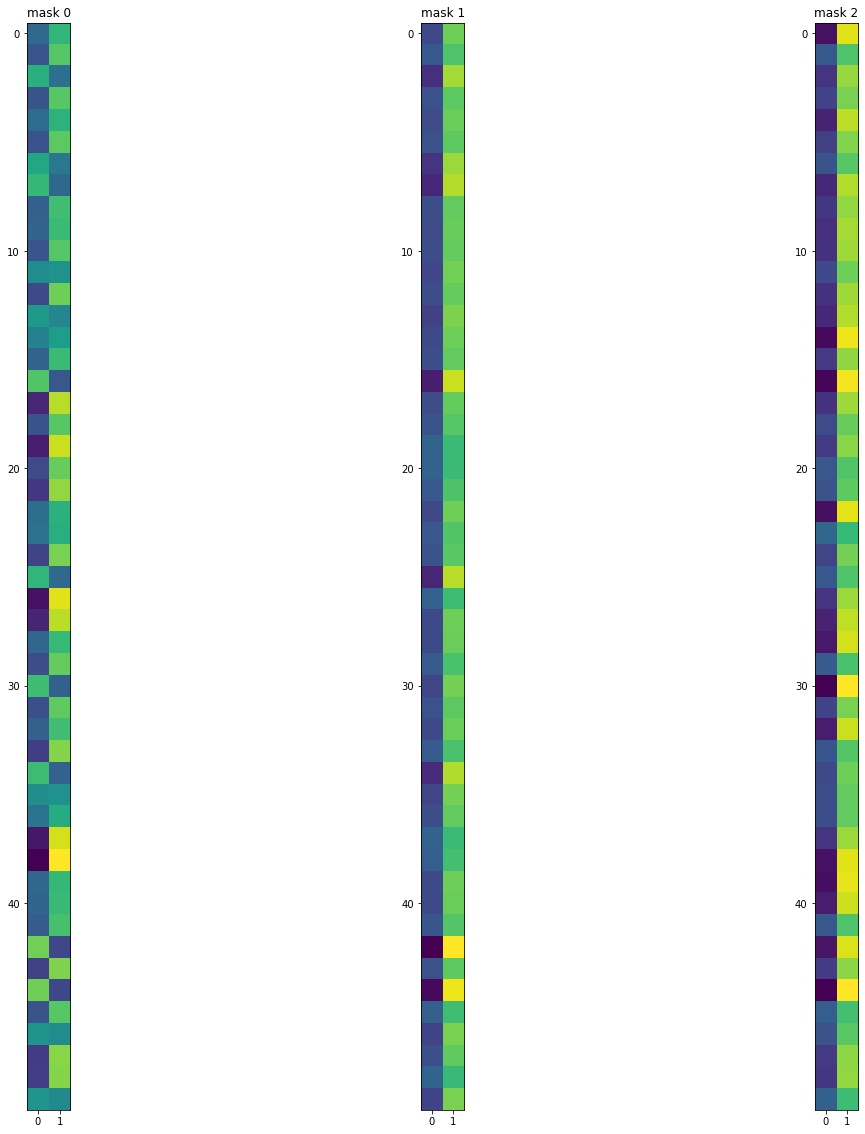

In [137]:
fig, axs = plt.subplots(1, 3, figsize=(20,20))

for i in range(3):
    axs[i].imshow(unsupervised_masks[i][:50])
    axs[i].set_title(f"mask {i}")

In [138]:
clf2 = tabnet(
    n_d=64, n_a=64, n_steps=5,
    gamma=1.5, n_independent=2, n_shared=2,
    cat_emb_dim=1,
    lambda_sparse=1e-3, momentum=0.3, clip_value=2.,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2),
    scheduler_params = {"gamma": 0.95,
                     "step_size": 20},
    scheduler_fn=torch.optim.lr_scheduler.StepLR, epsilon=1e-15
)

c:\Users\GuillemUPV\Anaconda3\envs\tfg\lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


In [139]:
clf2.fit(
    X_train=X_train, y_train=y_train,
    eval_set=[(X_train, y_train), (X_valid, y_valid)],
    eval_name=['train', 'valid'],
    eval_metric=['accuracy'],
    max_epochs=50 , patience=20,
    batch_size=1024, virtual_batch_size=128,
    drop_last=False,
    from_unsupervised=unsupervised_model,
) 

c:\Users\GuillemUPV\Anaconda3\envs\tfg\lib\site-packages\pytorch_tabnet\abstract_model.py:118: UserWarning: Pretraining: mask_type changed from sparsemax to entmax
  warnings.warn(wrn_msg)
c:\Users\GuillemUPV\Anaconda3\envs\tfg\lib\site-packages\pytorch_tabnet\abstract_model.py:248: UserWarning: Loading weights from unsupervised pretraining
  warnings.warn("Loading weights from unsupervised pretraining")


epoch 0  | loss: 1.18364 | train_accuracy: 0.45922 | valid_accuracy: 0.46392 |  0:00:05s
epoch 1  | loss: 1.05414 | train_accuracy: 0.47332 | valid_accuracy: 0.47739 |  0:00:10s
epoch 2  | loss: 1.04569 | train_accuracy: 0.48196 | valid_accuracy: 0.48662 |  0:00:16s
epoch 3  | loss: 1.03766 | train_accuracy: 0.45438 | valid_accuracy: 0.45728 |  0:00:21s
epoch 4  | loss: 1.04331 | train_accuracy: 0.48405 | valid_accuracy: 0.48976 |  0:00:27s
epoch 5  | loss: 1.04105 | train_accuracy: 0.49669 | valid_accuracy: 0.50175 |  0:00:33s
epoch 6  | loss: 1.03435 | train_accuracy: 0.4954  | valid_accuracy: 0.50157 |  0:00:38s
epoch 7  | loss: 1.03812 | train_accuracy: 0.47888 | valid_accuracy: 0.4809  |  0:00:44s
epoch 8  | loss: 1.0457  | train_accuracy: 0.49617 | valid_accuracy: 0.4988  |  0:00:50s
epoch 9  | loss: 1.03171 | train_accuracy: 0.49685 | valid_accuracy: 0.49991 |  0:00:57s
epoch 10 | loss: 1.03067 | train_accuracy: 0.48652 | valid_accuracy: 0.48957 |  0:01:02s
epoch 11 | loss: 1.03

c:\Users\GuillemUPV\Anaconda3\envs\tfg\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


In [140]:
from matplotlib import pyplot as plt
%matplotlib inline

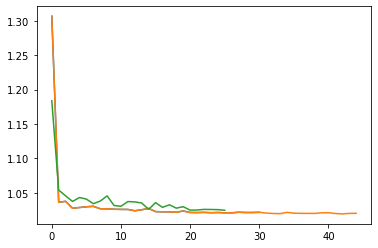

In [141]:
plt.plot(clf.history['loss'])
plt.plot(clf_loss.history['loss'])
plt.plot(clf2.history['loss'])

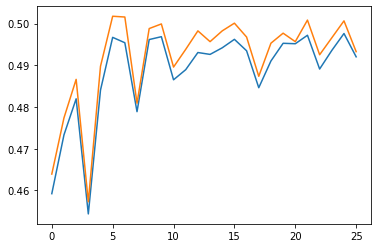

In [142]:
plt.plot(clf2.history['train_accuracy'])
plt.plot(clf2.history['valid_accuracy'])

In [143]:
logits2 = clf2.predict_proba(X_test)

In [144]:
preds2 = logits2.argmax(axis=1)
preds2

array([1, 2, 1, ..., 1, 2, 1], dtype=int64)

In [145]:
clf2.best_cost, clf2.best_epoch

(0.5017530909761949, 5)

In [146]:
test_acc2 = (preds2==y_test).mean()
test_acc2

0.4965873455082088

#### LOSS as EVAL METRIC

In [147]:
clf2_loss = tabnet(
    n_d=64, n_a=64, n_steps=5,
    gamma=1.5, n_independent=2, n_shared=2,
    cat_emb_dim=1,
    lambda_sparse=1e-3, momentum=0.3, clip_value=2.,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2),
    scheduler_params = {"gamma": 0.95,
                     "step_size": 20},
    scheduler_fn=torch.optim.lr_scheduler.StepLR, epsilon=1e-15
)

c:\Users\GuillemUPV\Anaconda3\envs\tfg\lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


In [148]:
clf2_loss.fit(
    X_train=X_train, y_train=y_train,
    eval_set=[(X_train, y_train), (X_valid, y_valid)],
    eval_name=['train', 'valid'],
    eval_metric=['logloss'],
    max_epochs=50 , patience=20,
    batch_size=1024, virtual_batch_size=128,
    drop_last=False,
    from_unsupervised=unsupervised_model,
) 

c:\Users\GuillemUPV\Anaconda3\envs\tfg\lib\site-packages\pytorch_tabnet\abstract_model.py:118: UserWarning: Pretraining: mask_type changed from sparsemax to entmax
  warnings.warn(wrn_msg)
c:\Users\GuillemUPV\Anaconda3\envs\tfg\lib\site-packages\pytorch_tabnet\abstract_model.py:248: UserWarning: Loading weights from unsupervised pretraining
  warnings.warn("Loading weights from unsupervised pretraining")


epoch 0  | loss: 1.18364 | train_logloss: 1.17237 | valid_logloss: 1.16035 |  0:00:05s
epoch 1  | loss: 1.05414 | train_logloss: 1.07827 | valid_logloss: 1.07771 |  0:00:11s
epoch 2  | loss: 1.04569 | train_logloss: 1.06269 | valid_logloss: 1.06925 |  0:00:17s
epoch 3  | loss: 1.03766 | train_logloss: 1.07472 | valid_logloss: 1.0754  |  0:00:23s
epoch 4  | loss: 1.04331 | train_logloss: 1.04425 | valid_logloss: 1.04632 |  0:00:29s
epoch 5  | loss: 1.04105 | train_logloss: 1.03755 | valid_logloss: 1.04081 |  0:00:35s
epoch 6  | loss: 1.03435 | train_logloss: 1.06374 | valid_logloss: 1.06404 |  0:00:41s
epoch 7  | loss: 1.03812 | train_logloss: 1.05914 | valid_logloss: 1.06439 |  0:00:47s
epoch 8  | loss: 1.0457  | train_logloss: 1.03893 | valid_logloss: 1.03935 |  0:00:53s
epoch 9  | loss: 1.03171 | train_logloss: 1.02495 | valid_logloss: 1.02699 |  0:00:59s
epoch 10 | loss: 1.03067 | train_logloss: 1.04951 | valid_logloss: 1.04918 |  0:01:04s
epoch 11 | loss: 1.03746 | train_logloss: 1

c:\Users\GuillemUPV\Anaconda3\envs\tfg\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


In [149]:
from matplotlib import pyplot as plt
%matplotlib inline

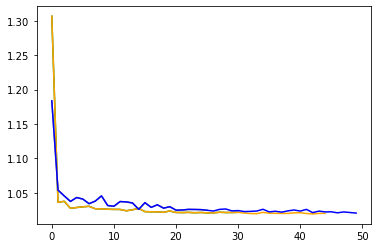

In [150]:
plt.plot(clf.history['loss'],color='green')
plt.plot(clf_loss.history['loss'],color='orange')
plt.plot(clf2.history['loss'],color='grey')
plt.plot(clf2_loss.history['loss'],color='blue')

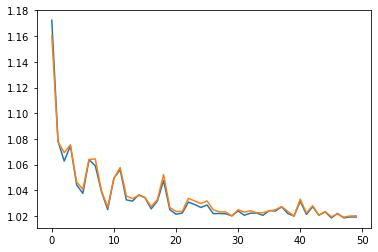

In [151]:
plt.plot(clf2_loss.history['train_logloss'])
plt.plot(clf2_loss.history['valid_logloss'])

In [152]:
logits2_loss = clf2_loss.predict_proba(X_test)

In [153]:
preds2_loss = logits2_loss.argmax(axis=1)
preds2_loss

array([1, 2, 1, ..., 1, 2, 1], dtype=int64)

In [154]:
clf2_loss.best_cost, clf2_loss.best_epoch

(1.019046351847052, 47)

In [155]:
test_acc2_loss = (preds2_loss==y_test).mean()
test_acc2_loss

0.4993543626637152

Obtenemos el mejor acierto usando Unsupervised learning y LogLoss como métrica de Validación.

- Batch-size 1-10% del training set.

In [156]:
test_acc, test_acc_loss, test_acc2, test_acc2_loss

(0.49787862018077844,
 0.497970854085962,
 0.4965873455082088,
 0.4993543626637152)

##### end

In [5]:
_aux_ = {1:2,2:3,3:4}

In [8]:
_aux_.update({4:5})
_aux_[5] = 6
_aux_

{1: 2, 2: 3, 3: 4, 4: 5, 5: 6}

In [10]:
if None:
    print("Si")
else:
    print("No")

No


In [10]:
import pandas as pd


xxx = pd.DataFrame({"nums":[1,2,3,4,5,6],"letras":["a","b","c","d","e","f"]})
features = ["nums"]
xxx.loc[:,[c for c in xxx.columns if c not in features]]

,letras
0,a
1,b
2,c
3,d
4,e
5,f


In [9]:
a,c = ([1,2],"b")
a

[1, 2]

In [12]:
a_, b_ = a
a_

1